# Meteo Cluster

## Подготовка данных

In [25]:
from src.data import load_data, dataset_to_dataframe, normalize_dataframe
from config import config

dataset_path = config.data_dir / "2025_1000.nc"

ds = load_data(file_path=dataset_path, pressure_level=0)

In [26]:
ds

<xarray.Dataset> Size: 11MB
Dimensions:  (time: 61, lat: 91, lon: 120)
Coordinates:
  * time     (time) datetime64[ns] 488B 2025-11-01T10:30:00 ... 2025-12-31T10...
  * lat      (lat) float64 728B -90.0 -88.0 -86.0 -84.0 ... 84.0 86.0 88.0 90.0
  * lon      (lon) float64 960B 0.0 3.0 6.0 9.0 12.0 ... 348.0 351.0 354.0 357.0
    lev      float64 8B 1e+03
Data variables:
    H        (time, lat, lon) float32 3MB ...
    T        (time, lat, lon) float32 3MB ...
    U        (time, lat, lon) float32 3MB ...
    V        (time, lat, lon) float32 3MB ...
Attributes: (12/35)
    CDI:                               Climate Data Interface version 1.7.1 (...
    Conventions:                       CF-1
    history:                           Wed Jan 28 15:09:34 2026: cdo sellevel...
    _NCProperties:                     version=1|netcdflibversion=4.5.0|hdf5l...
    History:                           Original file generated: Tue Nov 11 21...
    Comment:                           GMAO filename: d5124_m2_jan10.inst3_3d...
    ...                                ...
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2025-11-01
    RangeEndingTime:                   21:00:00.000000
    frequency:                         day
    NCO:                               4.3.7
    CDO:                               Climate Data Operators version 1.7.1 (...

In [27]:
meteo_df = dataset_to_dataframe(ds, features=["H", "T", "U", "V"])

In [28]:
meteo_df.head(5)

H         T         U         V     lev
time                lon lat                                                  
2025-11-01 10:30:00 0.0 -90.0 -5.423445 -4.133301  4.570474  2.031699  1000.0
                        -88.0 -5.423445 -4.133301  4.570474  2.031699  1000.0
                        -86.0 -5.423445 -4.133301  4.570474  2.031699  1000.0
                        -84.0 -5.847328 -3.828979  4.720197  1.897010  1000.0
                        -82.0 -6.308565 -3.814880  4.802876  1.922760  1000.0

In [29]:
norm_meteo_df = normalize_dataframe(ds, features=["H", "T"])

In [30]:
norm_meteo_df.head(5)

,H,T
0,0.347682,-0.271171
1,0.347682,-0.271171
2,0.347682,-0.271171
3,0.345259,-0.263639
4,0.115625,-0.190686


In [31]:
meteo_array = meteo_df.to_numpy()
norm_meteo_array = norm_meteo_df.to_numpy()

### Исследование кластеризаторов

In [32]:
from src.evaluation import stratified_sample_by_cluster, calculate_metrics

### Кластеризатор KMeans

In [33]:
from src.models import KMeansClusterer

kmeans_clusterer = KMeansClusterer(random_state=42)

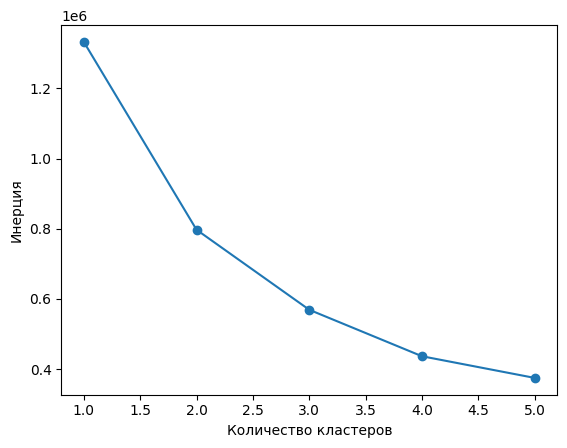

In [34]:
inertia_dict = kmeans_clusterer.elbow_method(norm_meteo_array, max_k=5)

In [35]:
kmeans_clusterer.update_params(n_clusters=5)
kmeans_clusterer.fit(norm_meteo_array)
labels = kmeans_clusterer.predict(norm_meteo_array)

In [ ]:
sample_df, sample_labels = stratified_sample_by_cluster(norm_meteo_array, labels, sample_size=5000)

kmeans_results = calculate_metrics(sample_df, sample_labels)

for metric, score in kmeans_results.items():
    print(f"{metric}: {score:.4f}")

silhouette_score: 0.3184
calinski_harabasz_score: 34079.6864
davies_bouldin_score: 0.9276
